# Realized betas and risk-adjusted returns {#sec-betas}

Now, we need to get the realized betas from the stocks returns with respect to the factors' principal components.

The following math and commentary is taken largely as-is from the paper. First, I present the theory, then the implementation in Python, and finally, the results.

## Methodology

The methodology is taken from @Distaso2013.


### Realized betas

Consider $i$ as a stock's index, with $I = 2000$ total stocks; $d$ as a factor's index, with $D = 6$ total factors; $t$ as a day index, with $T = 4000$ total days; $\lambda \in (1, 5)$ be the number of minutes in a within-day block; $m$ be the within-day block index, with $M_1 = 390$ or $M_5 = 78$ total blocks.

<!-- TODO: update numbers -->

Suppose we have $M$ equidistant observations within a day starting at time $t$, namely, $P_{i,t+\frac{\ell}{M}}$ and $F_{t+\frac{\ell}{M}}$ with $\ell = 0, \dots , M − 1$. We define the vector of realized betas as:

$$
    \hat{\beta}_{i,t,M} =
        \left[
            \sum_{\ell=0}^{M-1}
            \left(F_{t+\frac{\ell+1}{M}} - F_{t+\frac{\ell}{M}}\right)
            \left(F_{t+\frac{\ell+1}{M}} - F_{t+\frac{\ell}{M}}\right)^{\prime}
        \right]^{-1}
        \sum_{\ell=0}^{M-1}
        \left(F_{t+\frac{\ell+1}{M}} - F_{t+\frac{\ell}{M}}\right)
        \left(P_{i,t+\frac{\ell+1}{M}} - P_{i,t+\frac{\ell}{M}}\right) \tag{4}
$$

If we define:

$$
    \Delta_\ell F_{t} \coloneqq F_{t+\frac{\ell+1}{M}} - F_{t+\frac{\ell}{M}}
$$

$$
    \Delta_\ell P_{i, t} \coloneqq P_{i,t+\frac{\ell+1}{M}} - P_{i,t+\frac{\ell}{M}}
$$

Equation (4) can be rewritten as:

$$
    \hat{\beta}_{i,t,M} =
        \left[\sum_{\ell=0}^{M-1} \Delta_\ell F_{t} ~ \Delta_\ell F_{t}^{\prime}\right]^{-1}
        \sum_{\ell=0}^{M-1} \Delta_\ell F_{t} ~ \Delta_\ell P_{i, t} \tag{4'}
$$

### Risk-adjusted returns

To get the daily returns and alphas, we must move to discrete time. For $t = 1, \ldots, T$:

\begin{align*}
    r_{i,t+1} &= \int_{t}^{t+1} dP_i(s) = \mu_{i,t} + \Sigma_{j,t}^{\prime} \int_t^{t+1}dW_F(s) + \int_{t}^{t+1}\sigma_i(s)dW_i(s) \tag{6}\\
    f_{t+1} &= \int_{t}^{t+1} dF(s) = \mu_{F,t} + \Sigma_{F,t}\int_{t}^{t+1}dW_F(s) \tag{7}
\end{align*}

Where $\mu_{i,t}$ and $\mu_{F,t}$ are the drift parameters of the respective processes. Using the beta definition in (4), we get:

$$
    r_{i,t+1} = \alpha_{i, t} + f'_{t+1}\beta_{i,t} + \varepsilon_{i,t+1} + \eta_{i,t+1} \tag{8}
$$

Where $\varepsilon_{i, t+1}$ and $\eta_{i, t+1}$ are error terms independent of the risk factor and state variables.

Tha alphas will be calculated based on the risk-adjusted returns, which are defined as:

$$
    \hat{Z}_{i,t+1,M} = r_{i,t+1} - f_{t+1}\hat{\beta}_{i,t,M} \tag{Z}
$$

### The algorithm

#### Overview

The stocks and factor data were already processed into $\Delta_\ell F_{t}$ and $\Delta_\ell P_{i, t}$ formats.

The first step is, for each stock $i$ and day $t$, to calculate the realized betas $\hat{\beta}_{i,t,M}$ via equation (4').

Then, aggregate the daily returns $r_{i,t+1} = \sum_{\ell = 0}^{M - 1} \Delta_\ell P_{i, t}$, and use equation ($Z$) to calculate the risk-adjusted returns.

All this must be done for the 1-minute and 5-minute frequencies.


#### Looping order

Consider $i$ as a stock's index, with $I = 2000$ total stocks; $d$ as a factor's index, with $D = 6$ total factors; $t$ as a day index, with $T = 4000$ total days; $\lambda \in (1, 5)$ be the number of minutes in a within-day block; $m$ be the within-day block index, with $M_1 = 390$ or $M_5 = 78$ total blocks.

There are many possible ways to organized the beta calculations, given that we have one result for each day, stock, factor, and frequency. Performance and readability (easily matching the code with the mathematical equations) are the main concerns.

The first concern is the memory constraint: data for all stocks & days cannot fit in memory at once. Thus, the first/outer loop must be over stocks or days. While over days is a possibility, it might not be as intuitive. Also the `.parquet` data was ordered by `permno` exactly for this reason, to help querying the data by stock.

The second concern is about regularizing sizes: we must explicitly loop by frequencies, as we cannot combine objects of different sizes ($M_1$ and $M_2$ into a single tensor). Happily, as there are only $2$ frequencies, using a loop for it doesn't hurt performance much and helps with readability.

Finally, we can optimize the size of vectorized operations: if we loop by day, we do many ($T$) loops of operations in blocks $D$ factors $\times$ $M_1$ or $M_5$ observations. While if we loop by factor, we do $D$ loops of operations in blocks of $T$ days $\times$ $M_1$ or $M_5$ observations. The latter is more efficient, as it allows for larger vectorized operations, that still fit in memory.

Each dimension can be operated over via explicit loops, via tensor dimensions, or via merging them into block-matrices. The latter is the least readable, while the first is the least efficient. Thus, the optimal structure is looping over $i$, then $\lambda$, then operating over the tensor $(d, t, m)$. Alternatively, if we were willing to sacrifice some readability, we could loop by blocks of stocks, $\lambda$ and operate with the tensor $(i, d, t, m)$ in the GPU.

#### Pseudo-algorithm

The Pascal-like pseudocode belows outlines the procedure.

```pascal
procedure pca_high_freq(
    F_m1 : Matrix;      // Shape: (T*M1, d) | factor returns
    F_m5 : Matrix;      // Shape: (T*M5, d) | factor returns
    P_df : Matrix;      // Shape: (T*M1, I) | stock returns
    permnos_ordered : Vector // Shape: (I,) | list of permnos
);
    // Initialize containers for results:
    D = number of columns in F_m1;
    T = number of days in F_m1;
    betas_all = {"m1": [], "m5": []}
    adjusted_all = {"m1": [], "m5": []}

    // Stock loop:
    for each permno in permnos_ordered do
    begin
        P_m1 = query permno from P_df; // (T*M1,) + timestamps

        // Crop data to stock's window
        day_start = fist day of P_m1 in F_m1;
        day_end   = last day of P_m1 in F_m1;
        T_s = number of days in (day_start, day_end);

        F_m1_s = crop F_m1 to (day_start, day_end); // (T_s*M1, D)
        F_m5_s = crop F_m5 to (day_start, day_end); // (T_s*M5, D)
        P_m1_s = crop P_m1 to (day_start, day_end), set missing to 0; // (T_s*M1,)

        // Days for dataframe storing:
        days = P_m1_idx[day_start to day_end];
        days_lead = P_m1_idx[(day_start + 1) to day_end];

        // Aggregate to different frequencies, get t+1 day returns:
        P_m5_s  = aggregate P_m1_s into sum of 5-minute blocks; // (T_s*M5,)
        P_day_s = aggregate P_m5_s into sum of 1-day blocks, lead by 1; // (T_s - 1,)
        F_day_s = aggregate F_m5_s into sum of 1-day blocks, lead by 1; // (T_s - 1,)

        data_frequencies = {
            "m1": {"factors": F_m1_s, "returns": P_m1_s, "M": 390},
            "m5": {"factors": F_m5_s, "returns": P_m5_s, "M": 78}
        }
    
        // Frequency loop:
        for freq in ["m1", "m5"] do
            begin
                // Setup:
                F = data_frequencies[freq]["factors"];
                P = data_frequencies[freq]["returns"];
                M = data_frequencies[freq]["M"];

                // Reshape into tensors:
                FF = rearrange(F, '(t m) d -> t m d', t = T_s, m = M); // (T_s, M, D)
                PP = rearrange(P, '(t m) -> t m 1', t = T_s, m = M);   // (T_s, M, 1)

                // Compute cov. and var. across each day and factor
                cov = reduce(FF * PP, 't m d, t m 1 -> t d', 'sum'); // (T_s, D)
                var = reduce(FF * FF, 't m d -> t d', 'sum');        // (T_s, D)

                // Compute betas, with var = 0 -> beta = 0
                betas = divide(cov, var, fill = 0);   // (T_S, D)
                betas_lag = betas[0 to (T_s - 2), :]; // (T_s - 1, D)

                // Get the adjusted daily returns:
                P_day_hat = reduce(F_day_s * betas_lag, 't d -> t', 'sum'); // (T_s - 1,)
                P_day_adj = P_day_s - P_day_hat;                            // (T_s - 1,)

                // Store results:
                betas_all[freq] append (permno, days, betas_lag);
                adjusted_all[freq] append (permno, days_lead, P_day_adj);
            end;

        end;
    
    // Finalization:
    concatenate each of betas_all into (permno, day, beta1, ..., beta 6) dataframe;
    concatenate each of adjusted_all into (permno, day, adjusted_return) dataframe;
end.
```

## Code implementation

The problem is embarrassingly parallel at the stock level. At the same time, the big tensor operations could be done in the GPU. Below, I present first the sequential implementation, which presents the algorithm in a more readable way. In the appendix, I present both the GPU (via CuPy) and multiprocessing implementations.

CuPy is made to be equivalent to Numpy, such that we don't need to change almost nothing. But, the tensor operations aren't actually that big, and the overhead is not worth it. Multiprocessing adds a lot of setup cost (initializing workers, creating shared memory objects), and modifies heavily the main orchestrator. In another hand, it greately improves performance.

And core modules:

In [1]:
#| output: false
import os
if os.path.basename(os.getcwd()) == "src": os.chdir("..")

import polars as pl
import polars.selectors as cs
import numpy as np
from einops import reduce, rearrange

from tqdm import tqdm

from typing import TypedDict, Literal
from numpy.typing import NDArray

import src.utils as ut
import src.graphs as plot

ut.set_seed()

In [2]:
import importlib
importlib.reload(plot)

<module 'src.graphs' from 'c:\\Users\\ricar\\OneDrive\\A-Trabalho\\Freelance\\ra-distaso2026\\src\\graphs.py'>

Lets break the algorithm into pieces, starting by the results for a given frequency (inner iteration):

In [3]:
def freq_results(
    F: NDArray, P: NDArray, # (T_s * M, D), (T_s * M,)
    M: int,
    F_day_s: NDArray, P_day_s: NDArray, # (T_s - 1, D), (T_s - 1,)
    T_s: np.int64
) -> tuple[NDArray, NDArray]: # (T_s, D), (T_s - 1,)
    # Reshape into tensors:
    FF = rearrange(F, '(t m) d -> t m d', t = T_s, m = M) # (T_s, M, D)
    PP = rearrange(P, '(t m) -> t m 1', t = T_s, m = M)   # (T_s, M, 1)

    # Compute cov. and var. across each day and factor:
    cov = reduce(FF * PP, 't m d -> t d', 'sum') # (T_s, D)
    var = reduce(FF * FF, 't m d -> t d', 'sum') # (T_s, D)

    # Compute betas, with var = 0 -> beta = 0:
    betas = np.divide(
        cov, var,
        out = np.zeros_like(cov), where = var != 0
    ) # (T_S, D)
    betas_lag = betas[:-1, :] # (T_s - 1, D)

    # Get the adjusted daily returns:
    P_day_hat = reduce(F_day_s * betas_lag, 't d -> t', 'sum') # (T_s - 1,)
    P_day_adj = P_day_s - P_day_hat                            # (T_s - 1,)

    return betas, P_day_adj

Then, the outer loop:

In [4]:
class ResultsStock(TypedDict):
    permno: int
    day_range: tuple[np.int64, np.int64]
    m1: tuple[NDArray, NDArray] # (T_s, D), (T_s - 1,)
    m5: tuple[NDArray, NDArray] # (T_s, D), (T_s - 1,)

def stock_results(
    permno: int, P_df: pl.LazyFrame,
    F_m1: NDArray, F_m5: NDArray, # (T * M1, D), (T * M5, D)
    F_m1_idx: NDArray, # (T * M1,)
) -> ResultsStock:
    # Query permno from P_df (if query empty, should err):
    P_query = (
        P_df.filter(pl.col("permno") == permno)
        .select(["ts_min_ny", "log_return"])
        .collect()
    )

    P_m1 = P_query["log_return"].to_numpy()    # (T_s * M1,)
    P_m1_idx = P_query["ts_min_ny"].to_numpy() # (T_s * M1,)

    # Crop data to stock's window:
    idx_start: np.int64 = np.searchsorted(F_m1_idx, P_m1_idx[0])
    idx_end: np.int64 = np.searchsorted(F_m1_idx, P_m1_idx[-1], side = "right")
    day_start = idx_start // 390 # First minute of first day (left-closed)
    day_end = np.int64(np.ceil(idx_end / 390)) # First minute of last day + 1 (right-open)
    T_s = day_end - day_start

    F_m1_s = F_m1[day_start * 390 : day_end * 390, :] # (T_s * M1, D)
    F_m5_s = F_m5[day_start * 78 : day_end * 78, :]   # (T_s * M5, D)

    # Crop P_m1 to (day_start, day_end), set missing to 0:
    F_m1_s_idx = F_m1_idx[day_start * 390 : day_end * 390]

    fs_in_p = np.clip(np.searchsorted(F_m1_s_idx, P_m1_idx), 0, len(F_m1_s_idx) - 1)
    fs_in_p_exact = F_m1_s_idx[fs_in_p] == P_m1_idx
    # To solve out-of-bounds indexing (TODO: happens for permno 22859)

    P_m1_s = np.zeros(T_s * 390, dtype = np.float64) # (T_s * M1,)
    P_m1_s[fs_in_p[fs_in_p_exact]] = P_m1[fs_in_p_exact]

    # Aggregate to different frequencies, get t+1 day returns:
    P_m5_s  = reduce(P_m1_s, '(t m) -> t', 'sum', m = 5)             # (T_s * M5,)
    P_day_s = reduce(P_m5_s, '(t m) -> t', 'sum', m = 78)[1:]        # (T_s - 1,)
    F_day_s = reduce(F_m5_s, '(t m) d -> t d', 'sum', m = 78)[1:, :] # (T_s - 1, D)

    # Frequency loop:
    results_permno: ResultsStock = {
        "permno": permno,
        "day_range": (day_start, day_end),
        "m1": freq_results(F_m1_s, P_m1_s, 390, F_day_s, P_day_s, T_s),
        "m5": freq_results(F_m5_s, P_m5_s, 78, F_day_s, P_day_s, T_s)
    }

    return results_permno
# Note: it would be better to save 390, 78 as constants

Finally, the main orchestrator:

In [5]:
class ResultsRealized(TypedDict):
    permno: list[int]
    day_range: list[tuple[np.int64, np.int64]]
    m1: list[tuple[NDArray, NDArray]] # (T_s, D), (T_s - 1,)
    m5: list[tuple[NDArray, NDArray]] # (T_s, D), (T_s - 1,)

def betas_returns_realized(
    permnos_ordered: NDArray, P_df: pl.LazyFrame, # (I,)
    F_m1: NDArray, F_m5: NDArray, # (T * M1, D), (T * M5, D)
    F_m1_idx: NDArray, # (T * M1,)
    quiet: bool = False,
) -> ResultsRealized:
    I = len(permnos_ordered)

    F_m1 = np.ascontiguousarray(F_m1)
    F_m5 = np.ascontiguousarray(F_m5)
    F_m1_idx = np.ascontiguousarray(F_m1_idx)

    if not quiet: print(f"Starting stock loop for {I} stocks...")
    results: ResultsRealized = {"permno": [], "day_range": [], "m1": [], "m5": []}

    for permno in tqdm(permnos_ordered, disable = quiet, total = I):
        results_stock = stock_results(permno, P_df, F_m1, F_m5, F_m1_idx)
        results["permno"].append(results_stock["permno"])
        results["day_range"].append(results_stock["day_range"])
        results["m1"].append(results_stock["m1"])
        results["m5"].append(results_stock["m5"])

    return results

Some performance considerations:

- `F_m1` and `F_m5` are turned into contiguous arrays. `P_m1` and `P_m5` are already created contiguously.
- `freq_loop()` could be JIT-compiled with numba, but it would not work with the einops package. The performance gain is not that significant.


## Calculating the betas and risk-adjusted returns

Loading data:

In [6]:
data_pc_1 = pl.read_csv("data/pca_1min.csv")
data_pc_5 = pl.read_csv("data/pca_5min.csv")

F_m1, F_m5 = (
    x.select(cs.starts_with("pc_")).to_numpy() for x in [data_pc_1, data_pc_5]
)
F_m1_idx, F_m5_idx = (
    x["datetime"]
    .str.strptime(pl.Datetime, "%Y-%m-%d %H:%M")
    .to_numpy().astype("datetime64[m]").astype(np.uint32)
    for x in [data_pc_1, data_pc_5]
)
D = F_m1.shape[1]

permnos_ordered = pl.read_csv("data/stocks_raw/counts_permno.csv")["permno"].to_numpy()

P_filepath = "data/stocks_1min_returns.parquet"
P_df = pl.scan_parquet(P_filepath, parallel = "row_groups")

As stated before, the code is actually run with multiprocessing. The logic is the same, and @sec-betas-mp shows the code for the multiprocessing infrastructure. Below, I import it and run the results.

In [ ]:
#| execute: false
from src import betas_mp

if 1: # Run only once
    results = betas_mp.betas_returns_realized_mp(
        permnos_ordered = permnos_ordered,
        P_filepath = P_filepath,
        F_m1 = F_m1, F_m5 = F_m5,
        F_m1_idx = F_m1_idx,
        max_workers = 6, chunksize = 20
    )

 80%|████████  | 1900/2364 [02:10<00:31, 14.56it/s]


Finally, we save the results into parquet files. Inside `save_results()`, some basic checks are run:

- All dataframes are indexed by `permno` and `ts_day_ny`, in the exact same way, except for the missing first day in the adjusted returns.
- The index is sorted by `permno` and `ts_day_ny`, without duplicate pairs.
- There are no NaNs, Infs, or nulls in the dataframes.

In [8]:
#| execute: false
if False: # Run only once
    ut.save_results(results, F_m1_idx, D)

### Checking results

Here, I present a simpler version of the code for a single stock, frequency, and day, to check if the results are correct. It is based on matching the day stamps themselves from P and F.

In [9]:
def single_result(permno: int, freq: str) -> tuple[NDArray, NDArray]:
    P_query = (
        P_df.filter(pl.col("permno") == permno)
        .select(["ts_min_ny", "log_return"])
        .collect()
    )

    P_m1 = P_query["log_return"].to_numpy()    # (T_s * M1,)
    P_m1_idx = P_query["ts_min_ny"].to_numpy() # (T_s * M1,)

    days_p = P_m1_idx // 1440
    day_min, day_max = days_p.min(), days_p.max()

    days_f = F_m1_idx // 1440
    days_f_s = np.unique(days_f[(day_min <= days_f) & (days_f <= day_max)])
    T_s = np.int64(len(days_f_s))

    F_m1_s = F_m1[np.isin(days_f, days_f_s), :]
    F_m1_s_idx = F_m1_idx[np.isin(days_f, days_f_s)]
    F_m5_s = F_m5[np.isin(F_m5_idx // 1440, days_f_s), :]

    mask_fs_in_p = np.isin(F_m1_s_idx, P_m1_idx)
    mask_p_in_fs = np.isin(P_m1_idx, F_m1_s_idx)
    P_m1_s = np.zeros(T_s * 390, dtype = np.float64)
    P_m1_s[mask_fs_in_p] = P_m1[mask_p_in_fs]

    P_m5_s  = reduce(P_m1_s, '(t m) -> t', 'sum', m = 5)             # (T_s * M5,)
    P_day_s = reduce(P_m5_s, '(t m) -> t', 'sum', m = 78)[1:]        # (T_s - 1,)
    F_day_s = reduce(F_m5_s, '(t m) d -> t d', 'sum', m = 78)[1:, :] # (T_s - 1, D)

    if freq == "m1":
        result_freq = freq_results(F_m1_s, P_m1_s, 390, F_day_s, P_day_s, T_s)
    elif freq == "m5":
        result_freq = freq_results(F_m5_s, P_m5_s, 78, F_day_s, P_day_s, T_s)

    return result_freq

Then, for some random stock-frequency pairs, we check if the results are the same, up to some numerical precision. It passes, and the results are correct.

In [10]:
def check_results(
    permno: int, freq: Literal["m1", "m5"], threshold: float = 1e-13
) -> tuple[float, float]:
    res = stock_results(permno, P_df, F_m1, F_m5, F_m1_idx)
    betas_code, adjusted_code = res[freq]

    betas_single, adjusted_single = single_result(permno, freq)

    means = (
        np.mean(np.abs(betas_code - betas_single) <= threshold),
        np.mean(np.abs(adjusted_code - adjusted_single) <= threshold)
    )

    return means

n_tests = 10
permnos = np.random.choice(permnos_ordered, size = n_tests, replace = False)
freqs = np.random.choice(["m1", "m5"], size = n_tests, replace = True)

In [11]:
if not all(
    check_results(permno, freq) == (1, 1)
    for permno, freq in zip(permnos, freqs)
):
    raise ValueError("`stock_results()` is not in accordance to `single_result()`.")

## Visualizing results

Lets visualize the results, as a first look, and to check their reasonability. The adjusted returns are interesting to compare with the base returns in [src/data_stocks.ipynb](./data_stocks.ipynb)/@sec-stocks.

### The datasets

First, lets select some random stocks to visualize, and print the datasets.

In [179]:
vis_permnos = (
    pl.read_csv("data/stocks_raw/counts_permno.csv")
    ["permno"].sample(4).to_numpy()
)

In [180]:
pl.scan_parquet("data/betas_1min.parquet").head(5).collect()

permno,ts_day_ny,beta_1,beta_2,beta_3,beta_4,beta_5,beta_6
u32,u32,f64,f64,f64,f64,f64,f64
10032,12146,-0.085846,0.561377,-0.547257,0.340261,-0.116859,0.635344
10032,12149,-0.063692,1.264317,0.103729,1.079935,-1.382808,2.39721
10032,12150,-0.175836,0.784855,0.561158,-0.174367,0.617653,0.587243
10032,12151,-0.051801,1.151908,-1.296084,-0.856966,0.615159,0.116852
10032,12152,0.007006,0.488782,-0.812786,-0.833815,-0.803676,0.326376


In [181]:
pl.scan_parquet("data/stocks_1min_adjusted.parquet").head(5).collect()

permno,ts_day_ny,adjusted_return
u32,u32,f64
10032,12149,-0.006831
10032,12150,-0.00011
10032,12151,0.000149
10032,12152,-0.008418
10032,12153,-0.02418


### Adjusted returns

For some random PERMNOs, we plot the log return, the adjusted return, and the difference (the adjustment). All colored by the sign of the adjustment:

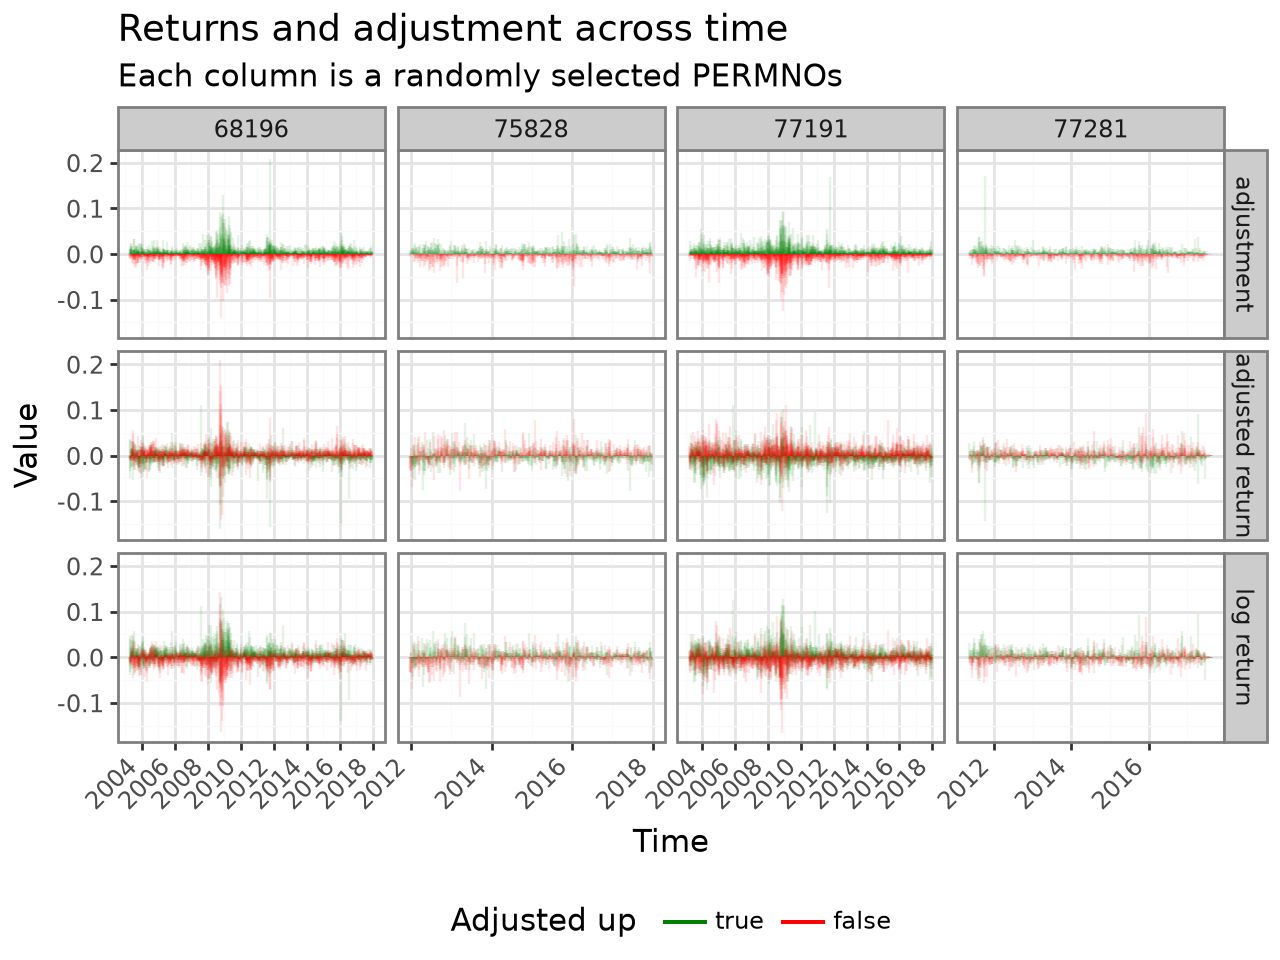

In [182]:
plot.adjusted_returns(vis_permnos)

To get a more general view, we can see the river plot of the adjusted returns for all stocks. Now, we also plot the 5-minute exercise.

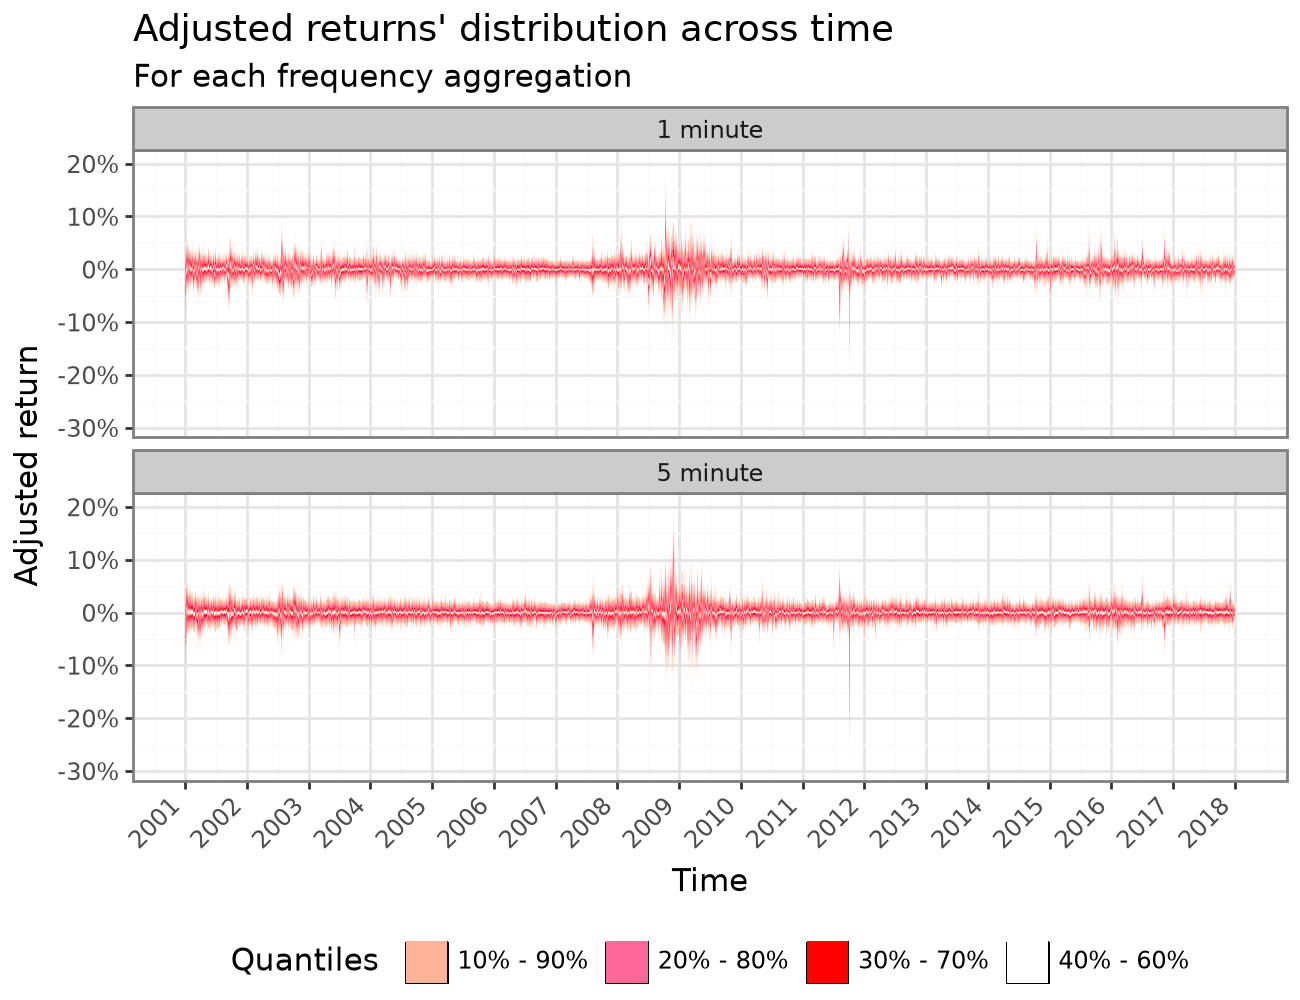

In [183]:
plot.adjusted_returns_river()

Lets understand the difference between the two frequencies.

In [11]:
plot.frequency_comparison()

statistic,adjusted return 1min,adjusted return 5min,adjusted return diff
str,f64,f64,f64
"""mean""",-0.000193,-0.00044,0.010786
"""std""",0.02516,0.027331,0.017108
"""min""",-6.334161,-6.344942,0.0
"""25%""",-0.009201,-0.009851,0.002036
"""50%""",0.0,0.0,0.005835
"""75%""",0.009052,0.009349,0.013088
"""max""",1.623521,5.629308,6.351686


### Betas

Now, we do a similar exercise for all the betas. First for a single stock:

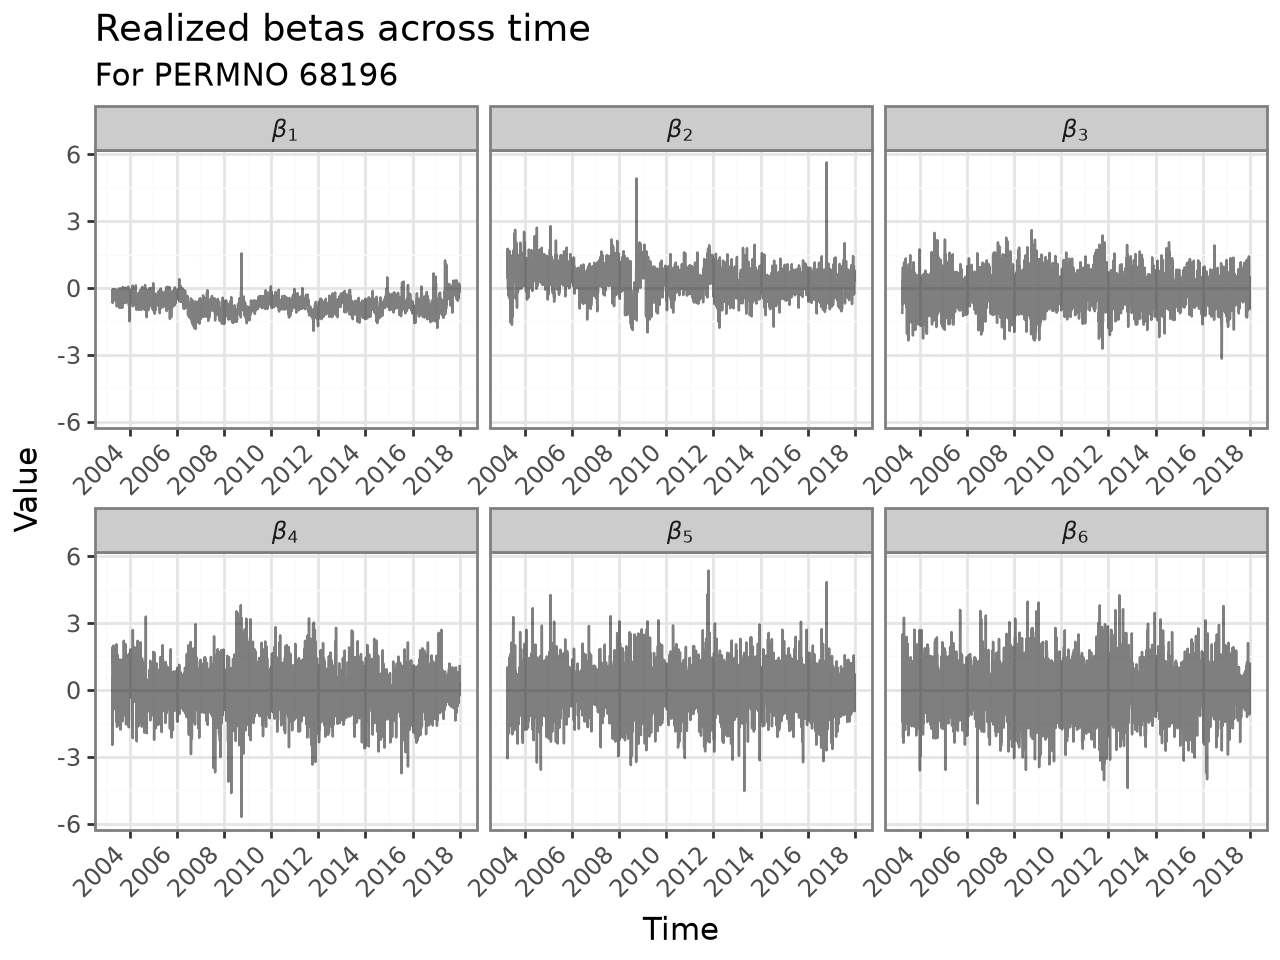

In [185]:
plot.betas(vis_permnos[0])

Then for all stocks, with river plots:

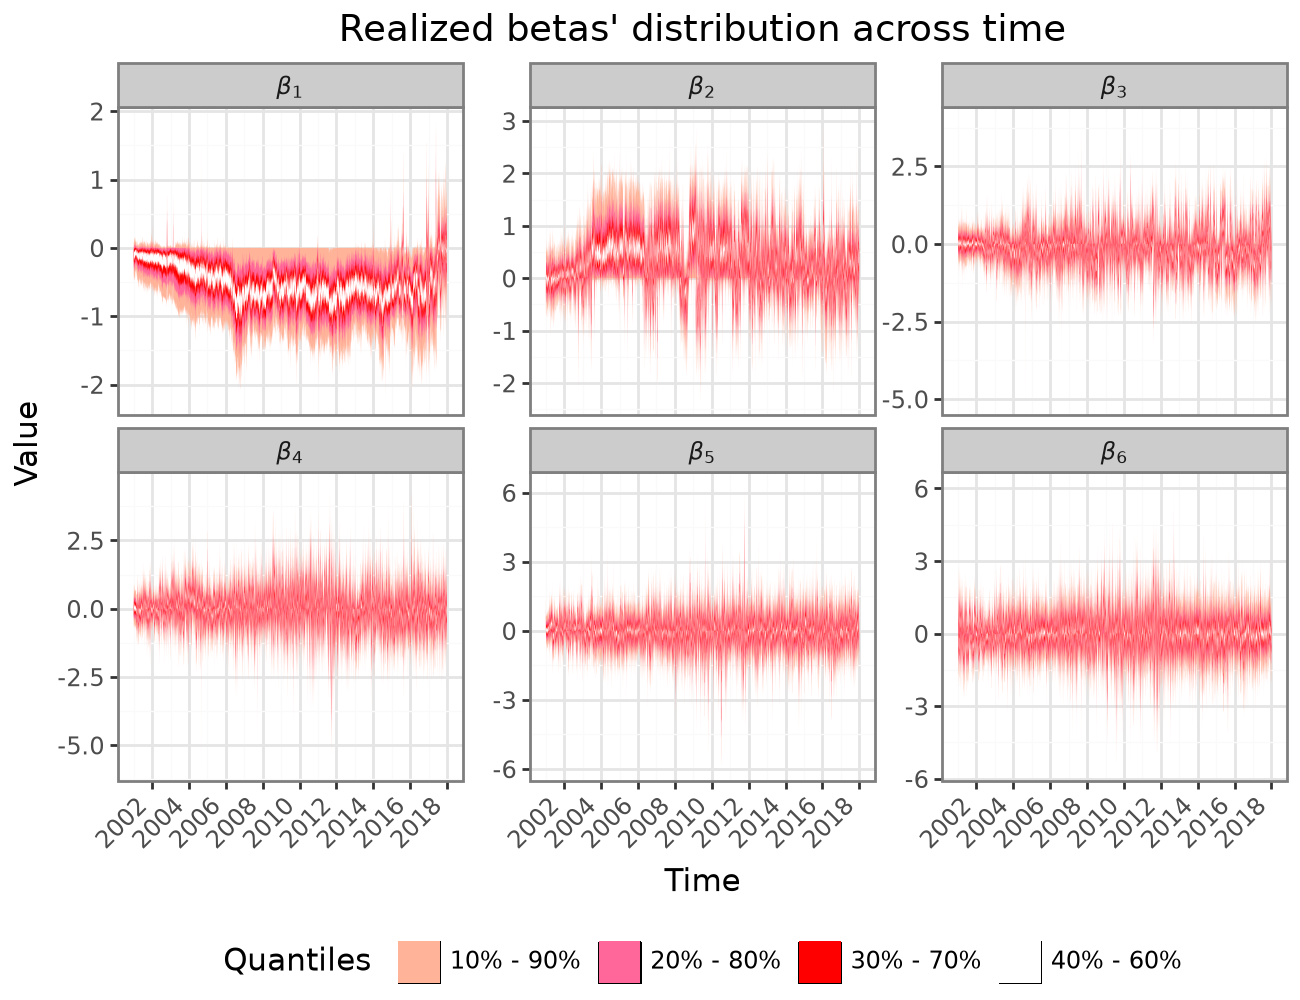

In [186]:
plot.betas_river()

And again for the 5-minute exercise:

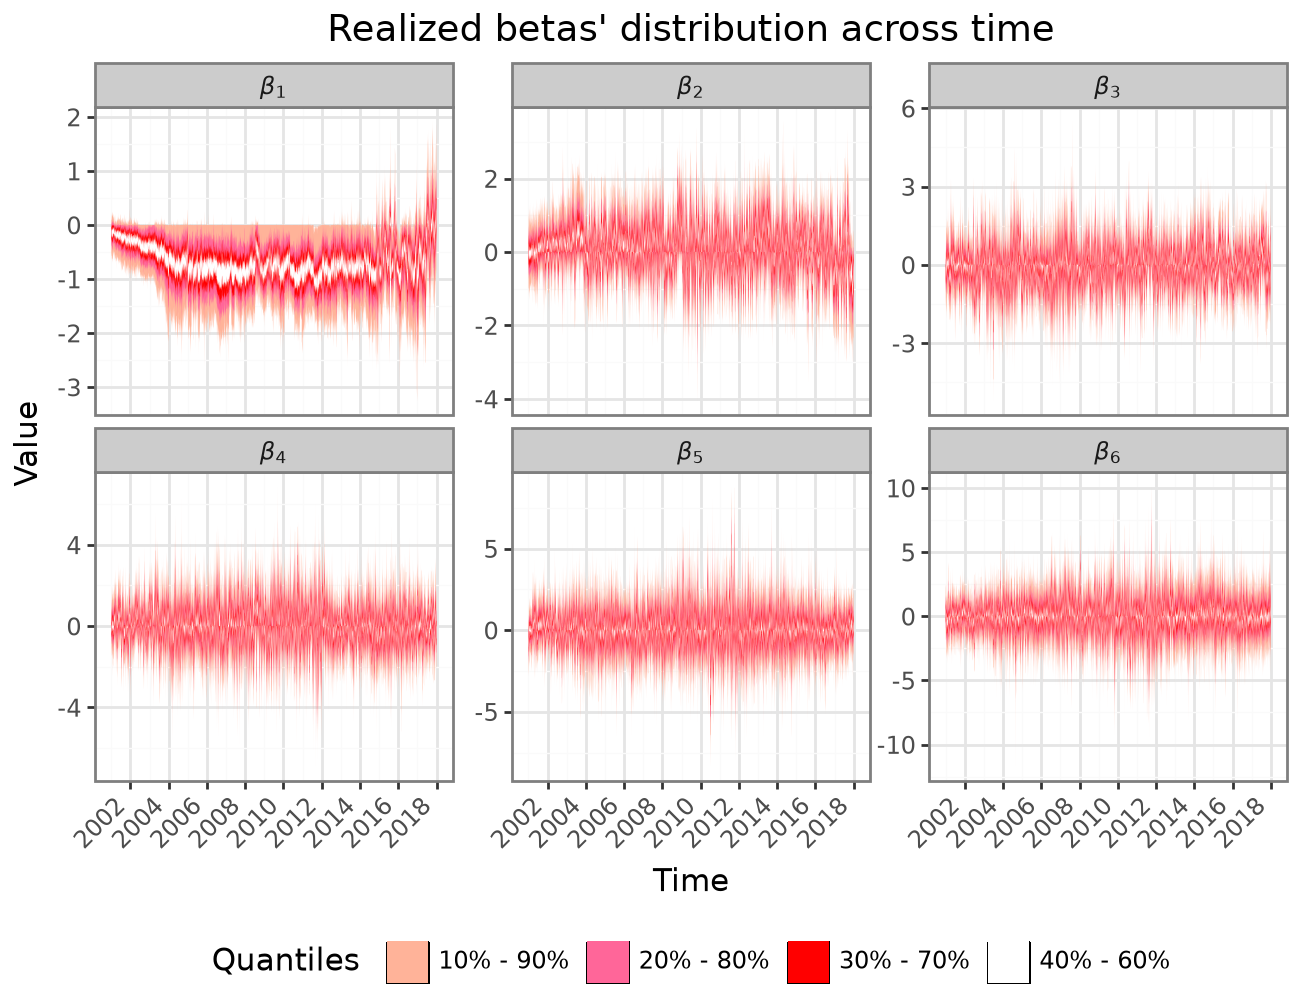

In [187]:
plot.betas_river("data/betas_5min.parquet")

Finally, for all betas together:

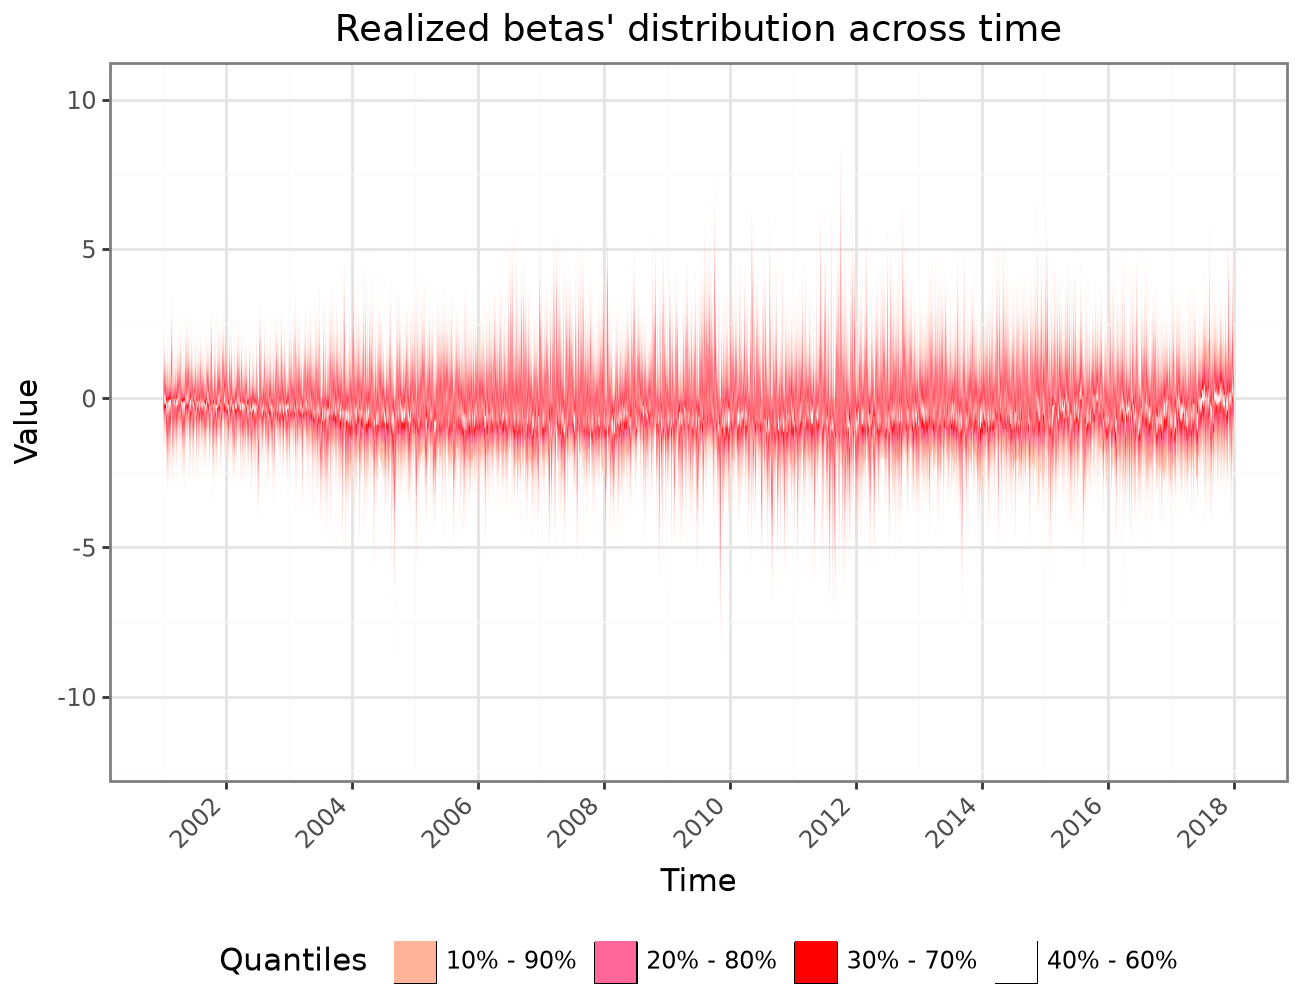

In [12]:
plot.betas_river("data/betas_5min.parquet", facet_betas = False)

We can also plot some statistics:

In [6]:
(
    pl.scan_parquet("data/betas_5min.parquet")
    .select(pl.col("^beta_.$"))
    .rename(lambda x: x.replace("_", " "))
    .describe()
    [2:]
)

statistic,beta 1,beta 2,beta 3,beta 4,beta 5,beta 6
str,f64,f64,f64,f64,f64,f64
"""mean""",-0.754928,0.085405,-0.045188,0.011261,0.006265,-0.023852
"""std""",0.805245,1.184127,1.529726,2.055262,2.479256,2.984621
"""min""",-141.681678,-222.804905,-416.011271,-444.871,-473.897769,-953.580566
"""25%""",-1.15786,-0.446359,-0.723584,-0.875457,-1.039951,-1.251895
"""50%""",-0.694373,0.004781,0.0,0.0,0.0,0.0
"""75%""",-0.242462,0.624554,0.614898,0.891176,1.048369,1.207348
"""max""",40.80044,71.083478,281.725165,795.09603,289.645411,559.232162


Lets understand the difference between the two frequencies. One can look at the individual betas with:

```python
plot.frequency_comparison("data/betas_1min.parquet", "data/betas_5min.parquet", "beta_1")
```

But below I use the average across all betas:

In [12]:
plot.frequency_comparison_all()

statistic,beta 1min,beta 5min,beta diff
str,f64,f64,f64
"""mean""",-0.06679,-0.120173,0.564046
"""std""",0.46288,0.819444,0.699123
"""min""",-92.899769,-340.730429,0.0
"""25%""",-0.266689,-0.457014,0.137261
"""50%""",-0.027907,-0.057572,0.371056
"""75%""",0.134262,0.213699,0.754502
"""max""",67.793202,179.490856,263.966128


## Appendix

Here I present the multiprocessing and GPU implementations.

### Multiprocessing code {#sec-betas-mp}

Setup and helpers to create shared memory arrays and initialize the worker processes:

In [189]:
#| execute: false

from multiprocessing import shared_memory
from multiprocessing.managers import SharedMemoryManager
from concurrent.futures import ProcessPoolExecutor
from threadpoolctl import ThreadpoolController

class SharedArrayMeta(TypedDict):
    name: str
    shape: tuple[int, ...]
    dtype: np.dtype

def create_shared_array(
    arr: NDArray, smm: SharedMemoryManager
) -> tuple[SharedArrayMeta, shared_memory.SharedMemory]:
    arr_c = np.ascontiguousarray(arr)
    shm = smm.SharedMemory(size = arr_c.nbytes)
    shared_arr = np.ndarray(arr_c.shape, dtype = arr_c.dtype, buffer = shm.buf)
    shared_arr[:] = arr_c[:]

    meta: SharedArrayMeta = {"name": shm.name, "shape": arr_c.shape, "dtype": arr_c.dtype}
    return meta, shm

WORKER_OBJS: dict[str, NDArray]
WORKER_SHMS: dict[str, shared_memory.SharedMemory]

def worker_init(shared_metas: dict[str, SharedArrayMeta]) -> None:
    # Permanently limit thread pools on the worker's process:
    _thread_controller = ThreadpoolController()
    _thread_controller.limit(limits = 1).__enter__() # Consider user_api = "blas"

    # Attach shared memory objects:
    global WORKER_OBJS, WORKER_SHMS
    WORKER_OBJS = {}
    WORKER_SHMS = {}

    for name, meta in shared_metas.items():
        shm = shared_memory.SharedMemory(name = meta["name"])
        WORKER_SHMS[name] = shm
        WORKER_OBJS[name] = np.ndarray(
            meta["shape"], dtype = meta["dtype"], buffer = shm.buf
        )

Then, the outer loop:

In [190]:
#| execute: false

def stock_results_mp(permno: int, P_filepath: str) -> ResultsStock:
    # Fetch global shared matrices directly from dictionary
    F_m1, F_m5, F_m1_idx = (WORKER_OBJS[x] for x in ["F_m1", "F_m5", "F_m1_idx"])

    # Query permno from P_df (if query empty, should err):
    P_query = (
        pl.scan_parquet(P_filepath)
        .filter(pl.col("permno") == permno)
        .select(["ts_min_ny", "log_return"])
        .collect()
    )

    P_m1 = P_query["log_return"].to_numpy()    # (T_s * M1,)
    P_m1_idx = P_query["ts_min_ny"].to_numpy() # (T_s * M1,)

    # Crop data to stock's window:
    idx_start: np.int64 = np.searchsorted(F_m1_idx, P_m1_idx[0])
    idx_end: np.int64 = np.searchsorted(F_m1_idx, P_m1_idx[-1], side = "right")
    day_start = idx_start // 390 # First minute of first day (left-closed)
    day_end = np.int64(np.ceil(idx_end / 390)) # First minute of last day + 1 (right-open)
    T_s = day_end - day_start

    F_m1_s = F_m1[day_start * 390 : day_end * 390, :] # (T_s * M1, D)
    F_m5_s = F_m5[day_start * 78 : day_end * 78, :]   # (T_s * M5, D)

    # Crop P_m1 to (day_start, day_end), set missing to 0:
    F_m1_s_idx = F_m1_idx[day_start * 390 : day_end * 390]

    fs_in_p = np.clip(np.searchsorted(F_m1_s_idx, P_m1_idx), 0, len(F_m1_s_idx) - 1)
    fs_in_p_exact = F_m1_s_idx[fs_in_p] == P_m1_idx
    # To solve out-of-bounds indexing (TODO: happens for permno 22859)

    P_m1_s = np.zeros(T_s * 390, dtype = np.float64) # (T_s * M1,)
    P_m1_s[fs_in_p[fs_in_p_exact]] = P_m1[fs_in_p_exact]

    # Aggregate to different frequencies, get t+1 day returns:
    P_m5_s  = reduce(P_m1_s, '(t m) -> t', 'sum', m = 5)             # (T_s * M5,)
    P_day_s = reduce(P_m5_s, '(t m) -> t', 'sum', m = 78)[1:]        # (T_s - 1,)
    F_day_s = reduce(F_m5_s, '(t m) d -> t d', 'sum', m = 78)[1:, :] # (T_s - 1, D)

    # Frequency loop:
    results_permno: ResultsStock = {
        "permno": permno,
        "day_range": (day_start, day_end),
        "m1": freq_results(F_m1_s, P_m1_s, 390, F_day_s, P_day_s, T_s),
        "m5": freq_results(F_m5_s, P_m5_s, 78, F_day_s, P_day_s, T_s)
    }

    return results_permno

Finally, the main orchestrator:

In [191]:
#| execute: false

def betas_returns_realized_mp(
    permnos_ordered: NDArray, P_filepath: str, # (I,)
    F_m1: NDArray, F_m5: NDArray, # (T * M1, D), (T * M5, D)
    F_m1_idx: NDArray, # (T * M1,)
    quiet: bool = False,
    max_workers: int | None = None, chunksize: int = 1
) -> ResultsRealized:
    I = len(permnos_ordered)
    results: ResultsRealized = {"permno": [], "day_range": [], "m1": [], "m5": []}

    with SharedMemoryManager() as smm:
        metas: dict[str, SharedArrayMeta] = {}
        shms: dict[str, shared_memory.SharedMemory] = {}
        for key, arr in [("F_m1", F_m1), ("F_m5", F_m5), ("F_m1_idx", F_m1_idx)]:
            meta, shm = create_shared_array(arr, smm)
            metas[key] = meta
            shms[key] = shm

        with ProcessPoolExecutor(
            initializer = worker_init, initargs = (metas,),
            max_workers = max_workers
        ) as executor:

            map_iterator = executor.map(
                stock_results_mp,
                permnos_ordered, [P_filepath] * I,
                chunksize = chunksize
            )

            for results_stock in tqdm(map_iterator, disable = quiet, total = I):
                results["permno"].append(results_stock["permno"])
                results["day_range"].append(results_stock["day_range"])
                results["m1"].append(results_stock["m1"])
                results["m5"].append(results_stock["m5"])

    return results

As these functions need to be exported into the worker processes, they must be defined at a `.py` script, [src/betas_mp.py](src/betas_mp.py). The notebook will import them from there.

### GPU code

With the GPU, we simply need to import the cupy package, setup it (make sure we have a tensor toolkit like cuda available), and replace it as the engine within the `freq_results()` function.

At the moment I haven't implemented the safe division for the GPU, but that is not the most critical aspect.

The GPU code is not expected to be that much faster, since we are working with relatively small matrices.

In [192]:
#| execute: false
import cupy as cp

if not cp.is_available():
    raise RuntimeError("Please properly setup CuPy to use GPU acceleration.")

In [193]:
#| execute: false

def freq_results_gpu(
    F: NDArray, P: NDArray, # (T_s * M, D), (T_s * M,)
    M: int,
    F_day_s: NDArray, P_day_s: NDArray, # (T_s - 1, D), (T_s - 1,)
    T_s: int
) -> tuple[NDArray, NDArray]: # (T_s, D), (T_s - 1,)
    F = cp.asarray(F)
    P = cp.asarray(P)
    F_day_s = cp.asarray(F_day_s)
    P_day_s = cp.asarray(P_day_s)

    # Reshape into tensors:
    FF = rearrange(F, '(t m) d -> t m d', t = T_s, m = M) # (T_s, M, D)
    PP = rearrange(P, '(t m) -> t m 1', t = T_s, m = M)   # (T_s, M, 1)

    # Compute cov. and var. across each day and factor:
    cov = reduce(FF * PP, 't m d -> t d', 'sum') # (T_s, D)
    var = reduce(FF * FF, 't m d -> t d', 'sum') # (T_s, D)

    # Compute betas, with var = 0 -> beta = np.nan:
    betas = (cov / var)       # (T_s - 1, D)
    betas_lag = betas[:-1, :] # (T_s - 1, D)

    # Get the adjusted daily returns:
    P_day_hat = reduce(F_day_s * betas_lag, 't d -> t', 'sum') # (T_s - 1,)
    P_day_adj = P_day_s - P_day_hat                            # (T_s - 1,)

    return cp.asnumpy(betas), cp.asnumpy(P_day_adj)